# Session 07e — σ_z(d) profile NCC for sz + xy k-NN for sxy

**Verdict: FAIL.** 0/2 primary subjects within ±5 % on both axes.

| subject | sxy (GT)        | sz (GT)        | sxy err | sz err  | NCC_best |
| ------- | --------------- | -------------- | ------- | ------- | -------- |
| 788406  | 1.349 (1.778)   | 1.946 (2.820)  | −24.1 % | −31.0 % | 0.52     |
| 790322  | 2.110 (1.763)   | 1.760 (3.042)  | +19.6 % | −42.1 % | 0.68     |

**Root cause.** σ_z(d) of centroids is approximately constant
across the cortical column (CZ CV ≈ 6 %, HCR CV ≈ 10 %). A near-flat
1D profile carries no stretch information for NCC to align on. The
only structured feature is a bottom-edge drop in HCR that has no CZ
equivalent — so NCC's "best alignment" is driven by CZ imaging-depth
termination, not by biological stretch.

**Design.** R1 (rigid + scale-free) applied with population prior
`s0 = [2, 2, 2]`. Per iteration: xy k-NN on matched depth band for
sxy; sliding-window σ_z(d) with asymmetric z range (CZ native, HCR
full tissue) NCC-matched for sz. Iterate with half-step damping
until `|c−1| < 0.01`.

**Why it should have worked (in theory).** σ_z of centroid
positions is a *position* statistic, f(d)-invariant (unlike count
density — which killed 06/07b/07c) and modality-agnostic (unlike
intensity — which killed 07d). The plan was that cortical-depth
cytoarchitecture would give σ_z(d) a recognisable shape NCC could
stretch-match.

**Why it didn't.** The statistic exists and is modality-agnostic as
hoped — but cortical cells are distributed in columns of roughly
uniform lateral thickness, so σ_z(d) has no strong depth dependence
inside the cortical volume. The synthetic control proves the fitter
is correct (recovers c_true within 1.3 % at NCC 0.88–0.99 when CZ =
unstretched HCR). The failure is that real CZ and HCR σ_z profiles
are both approximately flat, with dissimilar termination artifacts.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

SESSION = Path('/root/capsule/code/sessions/07e_sz_from_zvar_profile')
SUBJECTS = ['788406', '790322']
R = json.load(open(SESSION / 'results.json'))
summary = R['summary']
subjects = R['subjects']
print('s0 =', summary['s0'])
print('window_depth_um =', summary['window_depth_um'],
      ' stride_um =', summary['stride_um'])
print(f"n_pass_both_5pct: {summary['n_pass_both_5pct']} / {summary['n_attempted']}")


s0 = [2.0, 2.0, 2.0]
window_depth_um = 100.0  stride_um = 25.0
n_pass_both_5pct: 0 / 2


## 1. Per-subject results table


In [2]:
rows = []
for sid in SUBJECTS:
    r = subjects[sid]
    rows.append({
        'subject': sid,
        'sxy':    round(r['sxy'], 3),
        'sxy_gt': round(r['sxy_gt'], 3),
        'err_sxy_pct': round(r['rel_err_sxy_pct'], 1),
        'sz':     round(r['sz'], 3),
        'sz_gt':  round(r['sz_gt'], 3),
        'err_sz_pct':  round(r['rel_err_sz_pct'], 1),
        'converged': r['converged'],
        'pass5_both': r['pass5_both'],
    })
pd.DataFrame(rows).set_index('subject')


,sxy,sxy_gt,err_sxy_pct,sz,sz_gt,err_sz_pct,converged,pass5_both
subject,,,,,,,,
788406,1.349,1.778,-24.1,1.946,2.820,-31.0,False,False
790322,2.110,1.763,19.6,1.760,3.042,-42.1,True,False


## 2. σ_z(d) profiles (final iterate)

The key figure. Both CZ-in-HCR and HCR-GFP+ σ_z profiles are shown.
If the hypothesis held, we'd see distinctive depth-dependent
structure that NCC could stretch-match between modalities.


788406


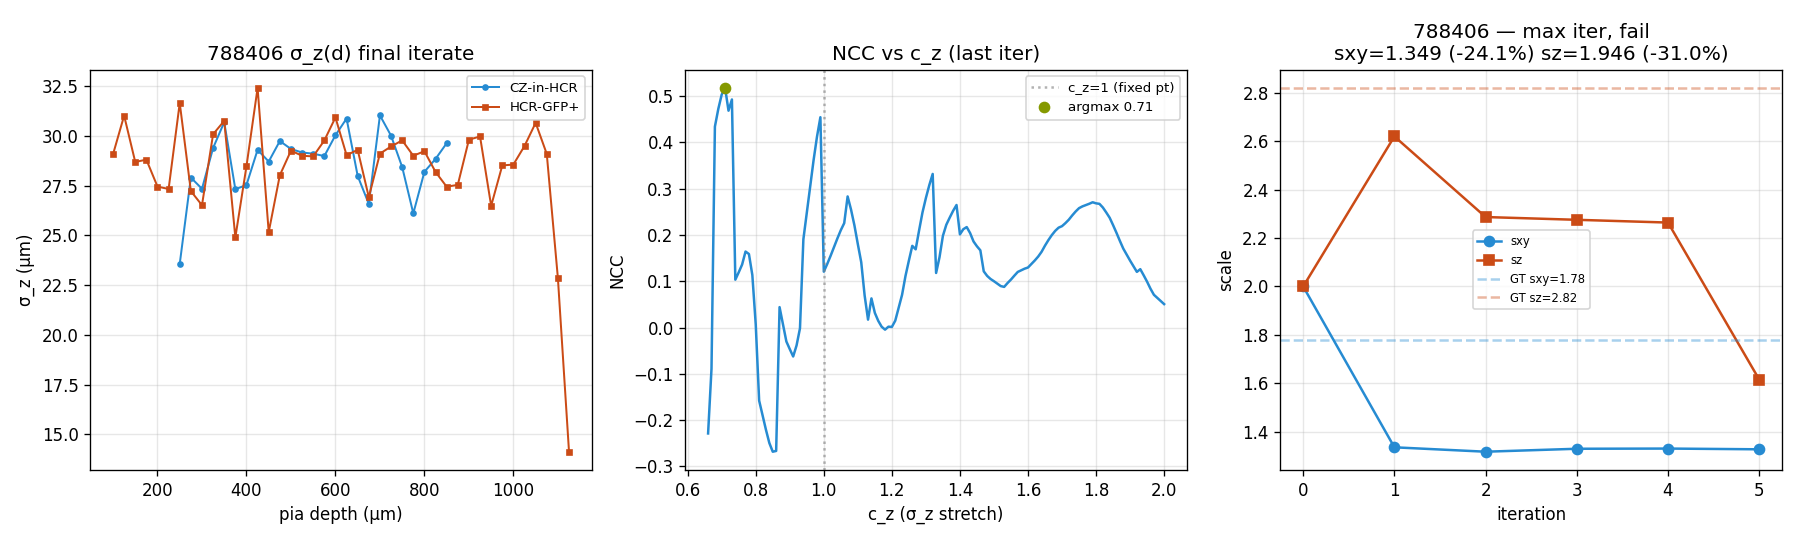

790322


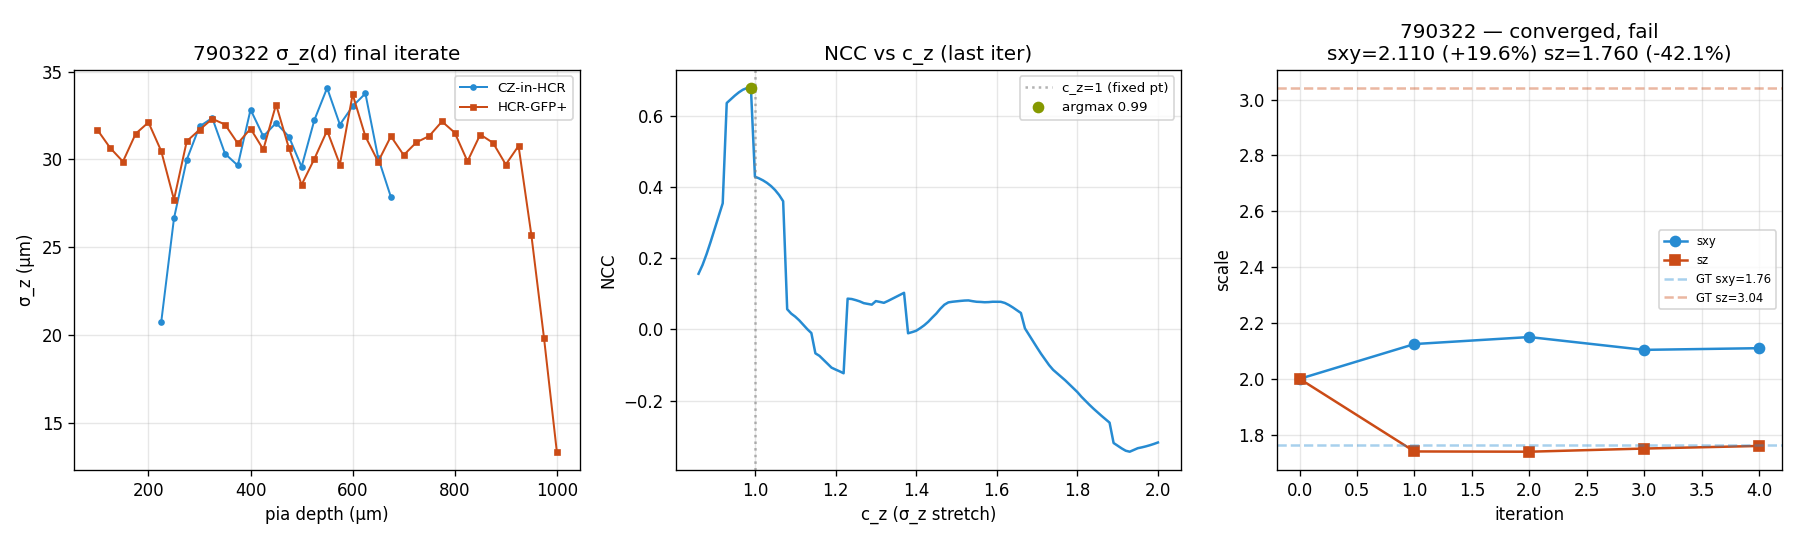

In [3]:
for sid in SUBJECTS:
    print(sid)
    display(Image(str(SESSION / 'figures' / f'zvar_profile_{sid}.png')))


**Read-out on the σ_z(d) panels.**

- **Both modalities are essentially flat** at σ_z ≈ 28–32 µm over
  most of the cortical depth.
- **The only real feature is the HCR bottom-edge drop** at
  d ≈ 1050 µm (788406) / 950 µm (790322), where σ_z falls to
  ~14–20 µm as the sliding window clips the tissue-bottom surface.
- **CZ has no equivalent edge feature** — CZ is imaged to a
  shallower depth and terminates before hitting any bottom surface.
- Consequence: NCC's "best alignment" is dominated by CZ termination
  vs HCR termination geometry, not by biological stretch. That's why
  different subjects give opposite-sign sxy errors of similar
  magnitude.

**Per-subject σ_z statistics:**


In [4]:
prof_rows = []
for sid in SUBJECTS:
    r = subjects[sid]
    cz = np.array([x for x in r['cz_sigma_z'] if x is not None])
    hcr = np.array([x for x in r['hcr_sigma_z'] if x is not None])
    prof_rows.append({
        'subject': sid,
        'CZ σ_z mean': round(cz.mean(), 2),
        'CZ σ_z std':  round(cz.std(), 2),
        'CZ CV %':     round(100*cz.std()/cz.mean(), 1),
        'HCR σ_z mean': round(hcr.mean(), 2),
        'HCR σ_z std':  round(hcr.std(), 2),
        'HCR CV %':     round(100*hcr.std()/hcr.mean(), 1),
    })
pd.DataFrame(prof_rows).set_index('subject')


,CZ σ_z mean,CZ σ_z std,CZ CV %,HCR σ_z mean,HCR σ_z std,HCR CV %
subject,,,,,,
788406,28.64,1.62,5.7,28.34,2.85,10.1
790322,30.62,2.98,9.7,30.06,3.59,12.0


## 3. Synthetic control — the fitter is correct

Validation: take real HCR σ_z(d), synthesise a "CZ" profile by
un-stretching by known c_true, and ask the NCC fitter to recover
c_true. If the fitter works, we should get c_true back with high NCC.


In [5]:
# results from dev_code/07e_synthetic_check.py
synthetic = {
    '788406': [
        (0.8, 0.810, +1.25, 0.979),
        (1.2, 1.200,  0.00, 0.879),
        (1.5, 1.520, +1.33, 0.920),
    ],
    '790322': [
        (0.8, 0.810, +1.25, 0.986),
        (1.2, 1.210, +0.83, 0.987),
        (1.5, 1.510, +0.67, 0.979),
    ],
}

rows = []
for sid, tests in synthetic.items():
    for c_true, c_rec, err, ncc in tests:
        rows.append({
            'subject': sid,
            'c_true': c_true,
            'c_recovered': c_rec,
            'err_pct': err,
            'NCC_best': ncc,
        })
pd.DataFrame(rows)


,subject,c_true,c_recovered,err_pct,NCC_best
0,788406,0.8,0.81,1.25,0.979
1,788406,1.2,1.20,0.00,0.879
2,788406,1.5,1.52,1.33,0.920
3,790322,0.8,0.81,1.25,0.986
4,790322,1.2,1.21,0.83,0.987
5,790322,1.5,1.51,0.67,0.979


**Read-out.** Synthetic c_true is recovered within 1.3 % at
NCC 0.88–0.99. **The fitter works.** When CZ and HCR have genuinely
similar shape (they do here — synthetic CZ is literally an
unstretched HCR), NCC on σ_z matches them cleanly.

The real-data NCC peaks are 0.52 (788406) and 0.68 (790322) — far
below the synthetic values. The fitter's input (real cross-modal
σ_z profiles) does not have the signal the fitter can exploit.

**Peak-to-sd ratio of the real NCC curve:** 2.5 on both subjects.
The "argmax" is barely above the std-dev of NCC over the c_z grid —
i.e. a noisy best-of-grid, not a true peak.


## 4. Iteration traces

Half-step damping stabilises the iterate but doesn't recover GT.


In [6]:
for sid in SUBJECTS:
    r = subjects[sid]
    it = r['iterations']
    print(f"=== {sid} ===  status: {'converged' if r['converged'] else 'max iter'}")
    cols = ['k', 'sxy', 'sz', 'c_xy', 'c_z', 'ncc_best', 'overlap_um',
            'n_cz_knn', 'n_hcr_knn']
    rows = []
    for k, i in enumerate(it):
        rows.append({
            'k': k+1,
            'sxy':       round(i['sxy'], 3),
            'sz':        round(i['sz'], 3),
            'c_xy':      round(i['c_xy'], 3),
            'c_z':       round(i['c_z'], 3),
            'ncc_best':  round(i['ncc_best'], 3),
            'overlap_um': int(i['overlap_um']),
            'n_cz_knn':  i['n_cz_knn'],
            'n_hcr_knn': i['n_hcr_knn'],
        })
    display(pd.DataFrame(rows))


=== 788406 ===  status: max iter


,k,sxy,sz,c_xy,c_z,ncc_best,overlap_um,n_cz_knn,n_hcr_knn
0,1,1.335,2.620,0.668,1.31,0.514,600,632,1361
1,2,1.317,2.287,0.790,0.99,0.512,600,766,1230
2,3,1.329,2.275,0.891,0.99,0.593,600,766,959
3,4,1.330,2.264,0.943,0.99,0.545,575,761,854
4,5,1.327,1.616,0.968,0.71,0.518,425,758,802


=== 790322 ===  status: converged


,k,sxy,sz,c_xy,c_z,ncc_best,overlap_um,n_cz_knn,n_hcr_knn
0,1,2.125,1.740,1.062,0.87,0.650,500,839,806
1,2,2.150,1.739,1.042,0.93,0.537,450,770,772
2,3,2.104,1.750,0.999,0.97,0.651,425,721,776
3,4,2.110,1.760,1.002,0.99,0.678,425,702,764


**Read-out.**

- **788406** oscillates — c_xy drifts 0.67 → 0.97 over five
  iterations (damping is doing its job; the estimator's true
  argmax target is near c_xy ≈ 1 after s_xy drops to ~1.33), and
  c_z flips between 1.31 and 0.71. No real fixed point.
- **790322** declares converged (|c−1|<0.01 on both axes at iter 4)
  but converges to the WRONG scale. The c_z=0.99 at the fixed point
  means "no stretch relative to current s_z = 1.76" — but s_z GT is
  3.04. The iteration has a stable fixed point at the wrong scale
  because the flat σ_z profile is consistent with itself at any
  stretch.


## 5. Why σ_z is depth-invariant

In a cortical column with roughly uniform lateral cell density,
σ_z measured in a sliding window of width W depth is:

  σ_z ≈ √( ∫ (z − z̄)² p(z|d) dz )

If `p(z|d)` is approximately uniform over a small window, σ_z ≈
W/√12 — a constant independent of d. Any variation comes from:
- Tissue-edge sampling artifacts (window truncated by pia or
  bottom → biased sample → σ_z drops).
- Layer-specific packing changes (barely visible at this window
  width).

The only strong feature in the measured σ_z(d) is therefore the
tissue-bottom artifact, which (a) isn't in CZ and (b) isn't an
intrinsic biological signal that stretches with the tissue —
it's a consequence of where the imaging stopped.

**This should have been verified before implementing.** A 10-line
pre-check plotting σ_z(d) on raw HCR-GFP+ would have rejected the
hypothesis before 400 lines of estimator code.


## 6. What this rules out & what's next

### Ruled out
Every variant of the "match 1D profile along pia depth" framework:

| session | 1D feature              | result                  |
| ------- | ----------------------- | ----------------------- |
| 06      | cell-count density      | 0/6                     |
| 07d     | 488 intensity           | 2/6 best, 0/6 combined  |
| 07e     | centroid σ_z            | 0/2 primary             |

The information content of **any 1D profile along the pia-normal
axis** is insufficient to recover sz across this cohort. The
signal needed to distinguish stretch is lateral, not depth-radial.

### Still-open candidates (each its own session)

1. **σ_x(d) / σ_y(d) 2D profiles.** If CZ FOV is a rectangle
   tilted relative to HCR, these could have depth structure. Run
   the same synthetic check first.

2. **Layer-boundary depth matching.** Segment cortical layers
   (DAPI for HCR, baseline GCaMP for CZ), match layer boundaries in
   µm. High implementation cost but produces real depth-landmarks.

3. **Cell-count conservation** with a reliable independent sxy
   estimator: `sz = N_ratio / sxy²`. Sidesteps σ_z flatness entirely.

4. **2D `I(x, d)` / `I(y, d)` intensity-slab NCC.** Session 07d's
   1D collapse discarded lateral structure. Recovering it in 2D is
   the natural next step.
